# CMP7005 PRAC1: India Air Quality Analysis, Machine Learning and Interactive Application

## Introduction

This notebook presents a complete Python-based data analysis project for the CMP7005 reassessment, *From Data to Application Development*. The air-quality context is used to demonstrate data handling, exploratory data analysis, machine learning, graphical application development, documentation, and version control. The main aim is not to make official environmental claims, but to show a reproducible analytical software workflow using the supplied Indian city air quality dataset.


## Project Objectives

The project objectives are to combine and inspect the supplied city datasets, prepare the data responsibly, conduct meaningful exploratory data analysis, build and evaluate AQI prediction models, develop a Streamlit graphical application, document version-control evidence, and reflect critically on the development process.


In [1]:
import sys
from pathlib import Path
import json

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

from src.data_loader import load_combined_dataset, save_combined_dataset, inspect_dataset
from src.preprocessing import clean_air_quality_data, POLLUTANT_COLUMNS, prepare_model_data
from src.eda_functions import (
    city_aqi_summary,
    city_date_coverage,
    comparable_city_subset,
    duplicate_city_dates,
    missing_value_summary,
    monthly_aqi_summary,
    pollutant_correlations,
    ranked_aqi_correlations,
    seasonal_aqi_summary,
    yearly_aqi_summary,
)
from src.model import feature_importance_table, get_feature_columns, load_model, training_test_metrics, train_and_compare_models
from src.utils import RAW_DATA_DIR, COMBINED_DATA_PATH, MODEL_PATH, RESULTS_PATH

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)


# Dataset Description

The supplied data consists of separate CSV files for Indian cities. Each file contains daily observations with city, date, pollutant measurements, AQI, and AQI_Bucket. The variables include particulate matter measures, gaseous pollutants, selected volatile organic compounds, and the AQI target used for modelling.


# Task 1: Data Handling

## Data Import and Dataset Combination

The raw data is supplied as multiple city CSV files rather than one single file. Combining them is appropriate because the files use the same schema and represent the same type of daily city-level observations. The original raw files are preserved in `data/raw/`, while the combined dataset is saved in `data/processed/air_quality.csv` for reproducible analysis.


In [2]:
raw_files = sorted(RAW_DATA_DIR.glob("*_data.csv"))
print(f"Number of raw city CSV files detected: {len(raw_files)}")
print([path.name for path in raw_files[:5]], "...")

data = save_combined_dataset(RAW_DATA_DIR, COMBINED_DATA_PATH)
inspection = inspect_dataset(data)
print("Combined dataset shape:", inspection["shape"])
print("Date range:", inspection["date_min"], "to", inspection["date_max"])
print("Number of cities:", len(inspection["cities"]))


Number of raw city CSV files detected: 26
['Ahmedabad_data.csv', 'Aizawl_data.csv', 'Amaravati_data.csv', 'Amritsar_data.csv', 'Bengaluru_data.csv'] ...


Combined dataset shape: (29531, 16)
Date range: 2015-01-01 00:00:00 to 2020-07-01 00:00:00
Number of cities: 26


The combined dataset contains 29,531 observations and 16 original variables across 26 cities. This is large enough to support city-level, temporal, and pollutant relationship analysis, but it also requires careful checking because the city files do not all have the same date coverage.


## Initial Inspection


In [3]:
display(data.head())
display(data.tail())
inspection_table = pd.DataFrame({
    "Data_Type": data.dtypes.astype(str),
    "Missing_Count": data.isna().sum(),
    "Unique_Values": data.nunique(dropna=False),
})
display(inspection_table)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory
29530,Visakhapatnam,2020-07-01,15.00,66.00,0.40,26.85,14.05,5.20,0.59,2.10,17.05,NaN,NaN,NaN,50.0,Good


,Data_Type,Missing_Count,Unique_Values
City,str,0,26
Date,datetime64[us],0,2009
PM2.5,float64,4598,11717
PM10,float64,11140,12572
NO,float64,3582,5777
NO2,float64,3585,7405
NOx,float64,4185,8157
NH3,float64,10328,5923
CO,float64,2059,1780
SO2,float64,3854,4762


The first and last rows confirm that the records have been combined in chronological city blocks and that `Date` has been parsed as a datetime variable. Most pollutant variables are numeric, while `City` and `AQI_Bucket` are categorical. This mixture of numeric and categorical variables justifies different preprocessing steps for EDA and modelling.


## Duplicate Assessment


In [4]:
clean_data = clean_air_quality_data(data)
exact_duplicates = int(data.duplicated().sum())
city_date_duplicates = duplicate_city_dates(clean_data)
print("Exact duplicate rows:", exact_duplicates)
print("Duplicate City-Date combinations:", len(city_date_duplicates))


Exact duplicate rows: 0
Duplicate City-Date combinations: 0


No exact duplicate records or duplicate City-Date combinations are present after loading. This means each city-date record can be treated as a single daily observation for the purposes of the analysis.


# Task 2: Exploratory Data Analysis

## Fundamental Data Understanding


In [5]:
print(f"Observations after preprocessing: {clean_data.shape[0]:,}")
print(f"Variables after adding date features: {clean_data.shape[1]}")
print("Original variables:", list(data.columns))
print("Cities represented:", sorted(clean_data["City"].unique()))

display(clean_data[["AQI"] + POLLUTANT_COLUMNS].describe().T)
display(clean_data["AQI_Bucket"].fillna("Missing").value_counts().to_frame("Records"))


Observations after preprocessing: 29,531
Variables after adding date features: 20
Original variables: ['City', 'Date', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'AQI', 'AQI_Bucket']
Cities represented: ['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Lucknow', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']


,count,mean,std,min,25%,50%,75%,max
AQI,24850.0,166.463581,140.696585,13.00,81.000,118.00,208.0000,2049.00
PM2.5,24933.0,67.450578,64.661449,0.04,28.820,48.57,80.5900,949.99
PM10,18391.0,118.127103,90.605110,0.01,56.255,95.68,149.7450,1000.00
NO,25949.0,17.574730,22.785846,0.02,5.630,9.89,19.9500,390.68
NO2,25946.0,28.560659,24.474746,0.01,11.750,21.69,37.6200,362.21
NOx,25346.0,32.309123,31.646011,0.00,12.820,23.52,40.1275,467.63
NH3,19203.0,23.483476,25.684275,0.01,8.580,15.85,30.0200,352.89
CO,27472.0,2.248598,6.962884,0.00,0.510,0.89,1.4500,175.81
SO2,25677.0,14.531977,18.133775,0.01,5.670,9.16,15.2200,193.86
O3,25509.0,34.491430,21.694928,0.01,18.860,30.84,45.5700,257.73


,Records
AQI_Bucket,
Moderate,8829
Satisfactory,8224
Missing,4681
Poor,2781
Very Poor,2337
Good,1341
Severe,1338


The descriptive statistics show that pollutant measurements and AQI values vary substantially across observations. The AQI category table also shows that some observations do not have an AQI_Bucket label, which is expected where AQI itself is missing. This reinforces the need to treat missing target values differently from missing predictor values.


## City-Specific Observation Periods


In [6]:
coverage = city_date_coverage(clean_data)
display(coverage)
display(coverage.assign(Start_Year=coverage["Start_Date"].dt.year)["Start_Year"].value_counts().sort_index().to_frame("Cities_Start_In_Year"))


,City,Start_Date,End_Date,Records,AQI_Records
0,Ahmedabad,2015-01-01,2020-07-01,2009,1334
4,Bengaluru,2015-01-01,2020-07-01,2009,1910
8,Chennai,2015-01-01,2020-07-01,2009,1884
10,Delhi,2015-01-01,2020-07-01,2009,1999
19,Lucknow,2015-01-01,2020-07-01,2009,1893
20,Mumbai,2015-01-01,2020-07-01,2009,775
14,Hyderabad,2015-01-04,2020-07-01,2006,1880
21,Patna,2015-06-01,2020-07-01,1858,1459
12,Gurugram,2015-11-27,2020-07-01,1679,1453
25,Visakhapatnam,2016-07-01,2020-07-01,1462,1171


,Cities_Start_In_Year
Start_Year,
2015,9
2016,1
2017,7
2018,1
2019,5
2020,3


The city coverage table is important because not all cities enter the dataset at the same time. Some cities have observations beginning in 2015, while others appear later. Therefore, city means and overall annual trends should be interpreted cautiously because they may partly reflect differences in data availability and changing city composition, not only changes in air quality.


## Data Preprocessing

The preprocessing keeps the raw data unchanged. The project removes duplicate rows where present, parses `Date`, converts pollutant and AQI columns to numeric values, treats negative pollutant values as invalid, and creates `Year`, `Month`, `Month_Name`, and `Season`. These temporal features support monthly, annual, and seasonal EDA and provide simple time-related predictors for the model.


In [7]:
display(clean_data[["Date", "Year", "Month", "Month_Name", "Season"]].head())
print("Rows before preprocessing:", len(data))
print("Rows after preprocessing:", len(clean_data))


,Date,Year,Month,Month_Name,Season
0,2015-01-01,2015,1,January,Winter
1,2015-01-02,2015,1,January,Winter
2,2015-01-03,2015,1,January,Winter
3,2015-01-04,2015,1,January,Winter
4,2015-01-05,2015,1,January,Winter


Rows before preprocessing: 29531
Rows after preprocessing: 29531


## Missing Data Analysis


,Variable,Missing_Count,Missing_Percent
0,Xylene,18109,61.32
1,PM10,11140,37.72
2,NH3,10328,34.97
3,Toluene,8041,27.23
4,Benzene,5623,19.04
5,AQI_Bucket,4681,15.85
6,AQI,4681,15.85
7,PM2.5,4598,15.57
8,NOx,4185,14.17
9,O3,4022,13.62


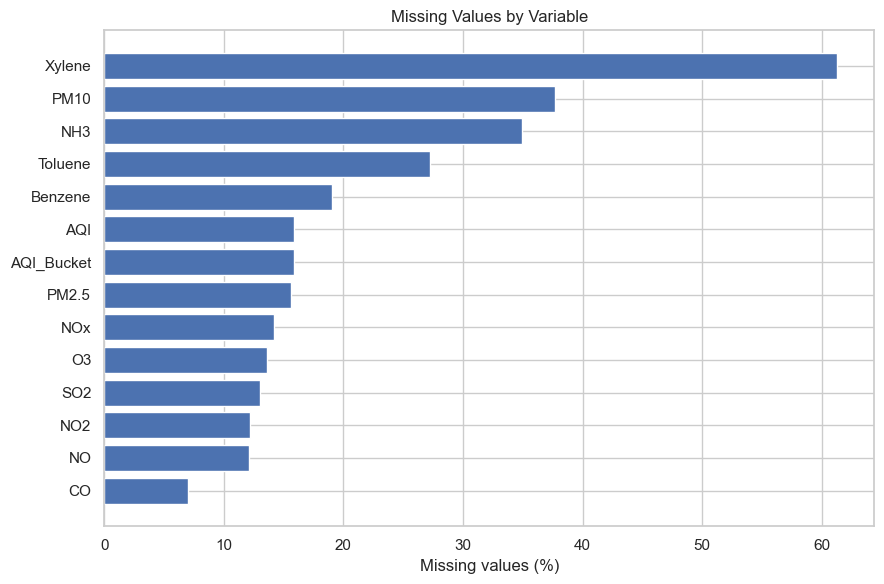

In [8]:
missing_summary = missing_value_summary(clean_data)
display(missing_summary)

plt.figure(figsize=(9, 6))
plot_data = missing_summary[missing_summary["Missing_Count"] > 0].sort_values("Missing_Percent")
plt.barh(plot_data["Variable"], plot_data["Missing_Percent"])
plt.xlabel("Missing values (%)")
plt.title("Missing Values by Variable")
plt.tight_layout()
plt.show()


Missingness is one of the main data-quality issues in this dataset. Xylene has the highest missing percentage, followed by PM10, NH3, Toluene, and Benzene. A single universal treatment would be inappropriate because variables have different roles. Missing AQI values cannot be filled as modelling targets, while missing predictor values can be imputed inside the modelling pipeline. Highly incomplete variables such as Xylene are retained for exploratory completeness but should be interpreted cautiously because their available observations are limited.


## Univariate Analysis


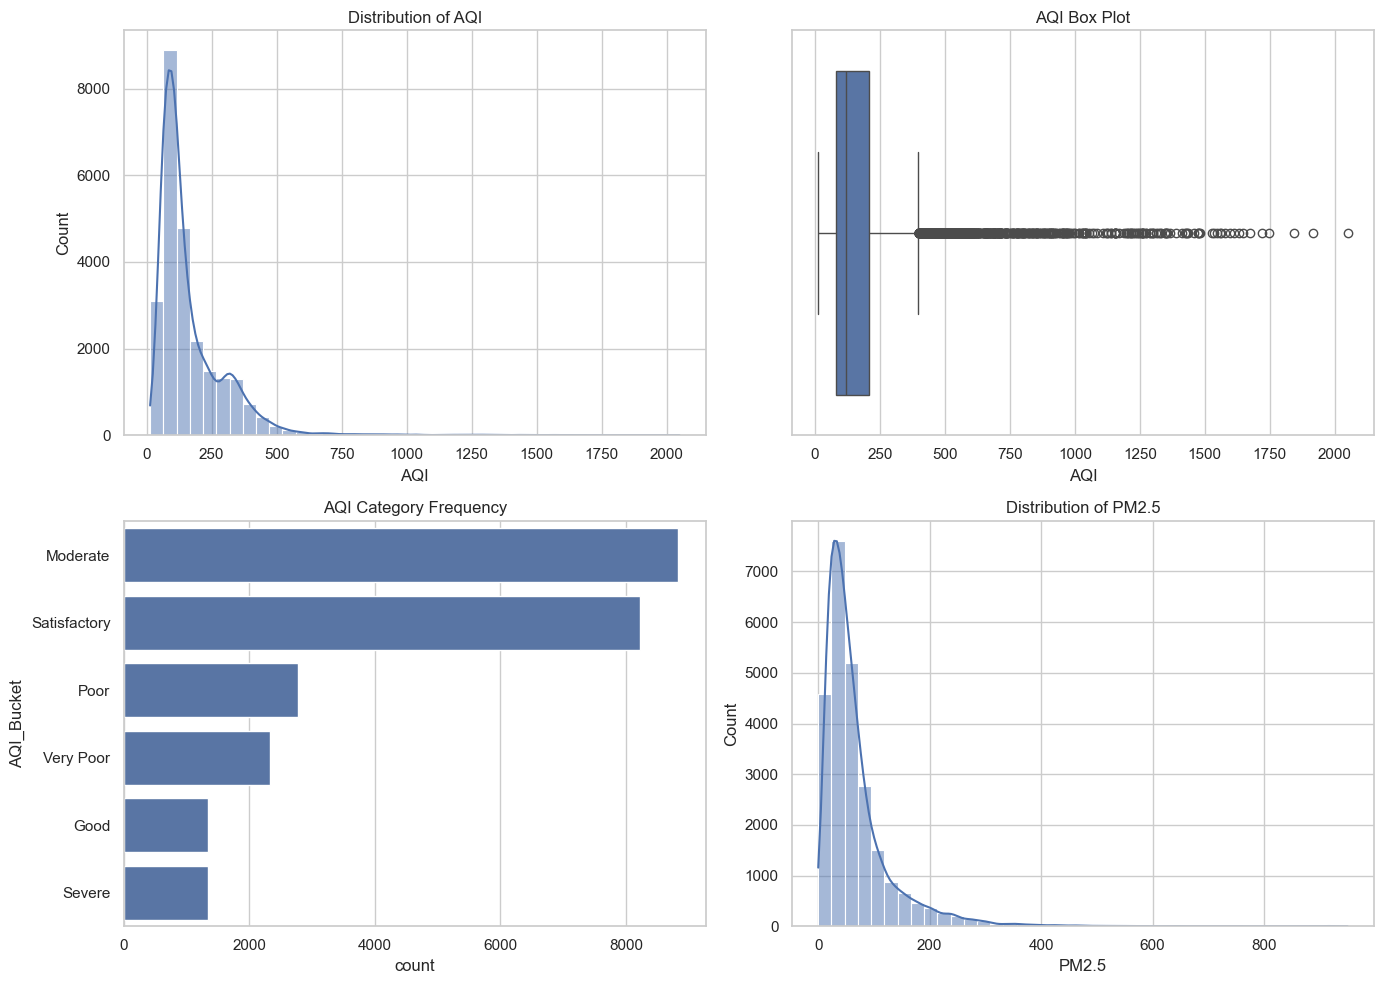

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.histplot(clean_data["AQI"].dropna(), bins=40, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of AQI")
sns.boxplot(x=clean_data["AQI"], ax=axes[0, 1])
axes[0, 1].set_title("AQI Box Plot")
category_order = clean_data["AQI_Bucket"].value_counts().index
sns.countplot(data=clean_data, y="AQI_Bucket", order=category_order, ax=axes[1, 0])
axes[1, 0].set_title("AQI Category Frequency")
sns.histplot(clean_data["PM2.5"].dropna(), bins=40, kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Distribution of PM2.5")
plt.tight_layout()
plt.show()


The AQI distribution is right-skewed, with many observations in lower and moderate ranges but a visible tail of higher AQI values. The box plot indicates extreme high-AQI observations, which are plausible in air-quality data and should not be removed without a strong reason. The AQI category count provides an interpretable view of how frequently the dataset records different air-quality classes.


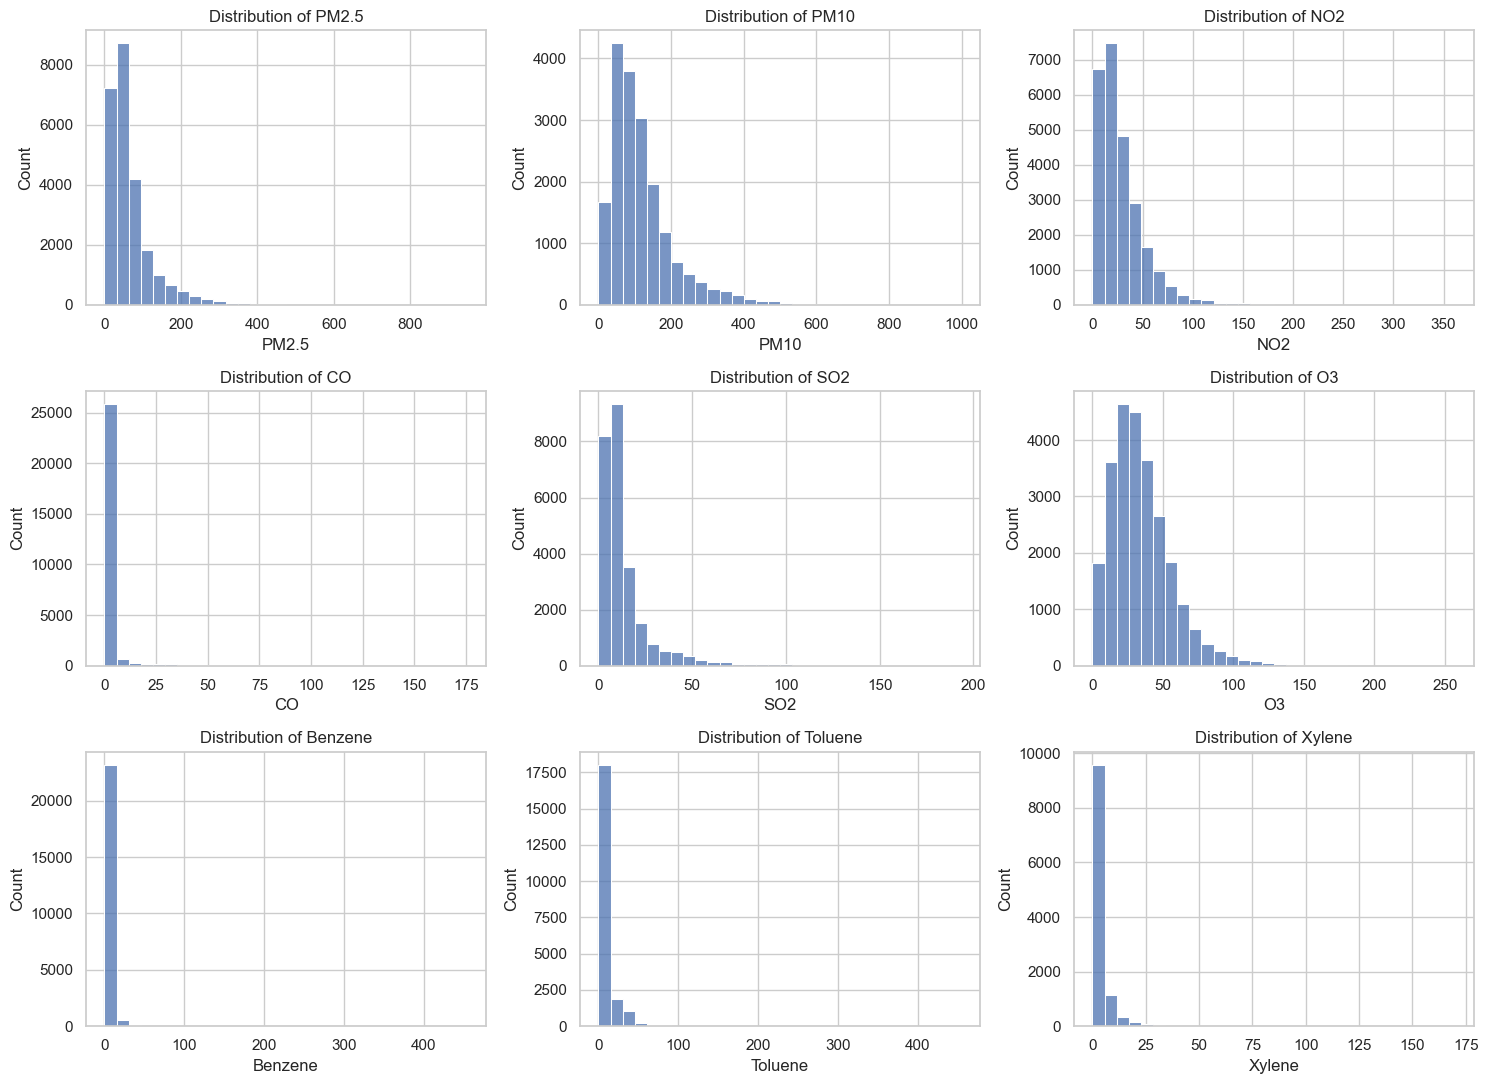

In [10]:
selected_pollutants = ["PM2.5", "PM10", "NO2", "CO", "SO2", "O3", "Benzene", "Toluene", "Xylene"]
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, pollutant in zip(axes.ravel(), selected_pollutants):
    sns.histplot(clean_data[pollutant].dropna(), bins=30, ax=ax)
    ax.set_title(f"Distribution of {pollutant}")
plt.tight_layout()
plt.show()


The pollutant distributions are generally skewed rather than normally distributed. This is common for environmental concentration data, where most daily values are moderate but occasional high-pollution days create long upper tails. The VOC variables, especially Xylene, must be interpreted with additional caution because high missingness reduces the representativeness of their distributions.


## Bivariate Analysis


,City,Mean_AQI,Median_AQI,Records
0,Ahmedabad,452.122939,384.5,1334
10,Delhi,259.487744,257.0,1999
21,Patna,240.782042,215.0,1459
12,Gurugram,225.123882,208.0,1453
19,Lucknow,217.973059,198.0,1893
23,Talcher,172.886819,128.5,698
16,Jorapokhar,159.251621,133.0,771
6,Brajrajnagar,150.280505,122.0,713
18,Kolkata,140.566313,94.0,754
13,Guwahati,140.111111,98.0,495


,City,Mean_AQI,Median_AQI,Records
20,Mumbai,105.352258,91.0,775
17,Kochi,104.284810,99.0,158
7,Chandigarh,96.498328,82.0,299
2,Amaravati,95.299643,78.0,841
4,Bengaluru,94.318325,86.0,1910
11,Ernakulam,92.359477,94.0,153
24,Thiruvananthapuram,75.878327,68.0,1052
9,Coimbatore,73.023256,75.0,344
22,Shillong,53.795122,48.0,205
1,Aizawl,34.765766,23.0,111


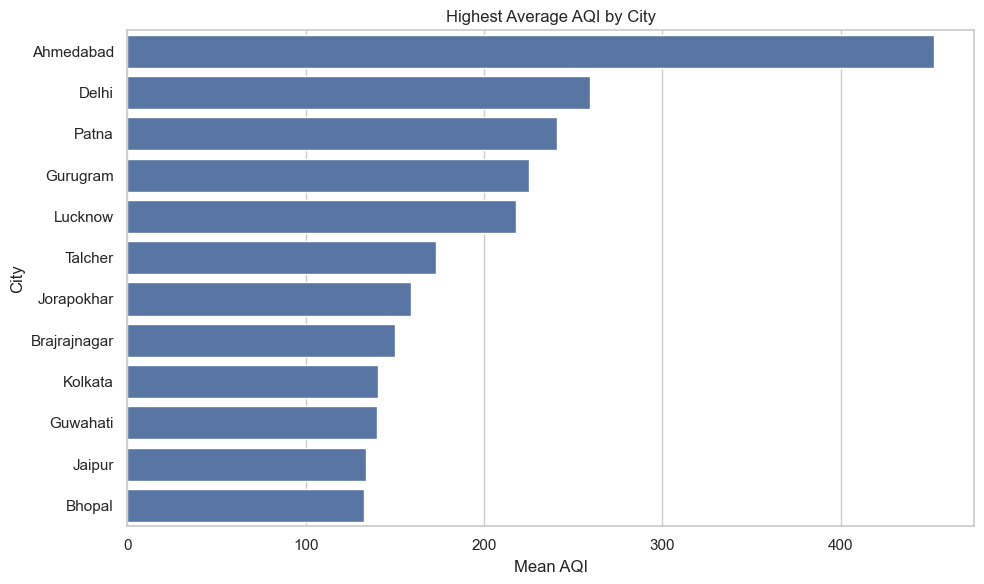

In [11]:
city_summary = city_aqi_summary(clean_data)
display(city_summary.head(10))
display(city_summary.tail(10))

plt.figure(figsize=(10, 6))
sns.barplot(data=city_summary.head(12), x="Mean_AQI", y="City")
plt.title("Highest Average AQI by City")
plt.xlabel("Mean AQI")
plt.ylabel("City")
plt.tight_layout()
plt.show()


Ahmedabad has the highest mean AQI in the combined dataset, while Aizawl has the lowest. This city-level comparison is useful, but it should not be read as a perfectly fair ranking of long-term air quality because cities have different observation periods and different amounts of missing data.


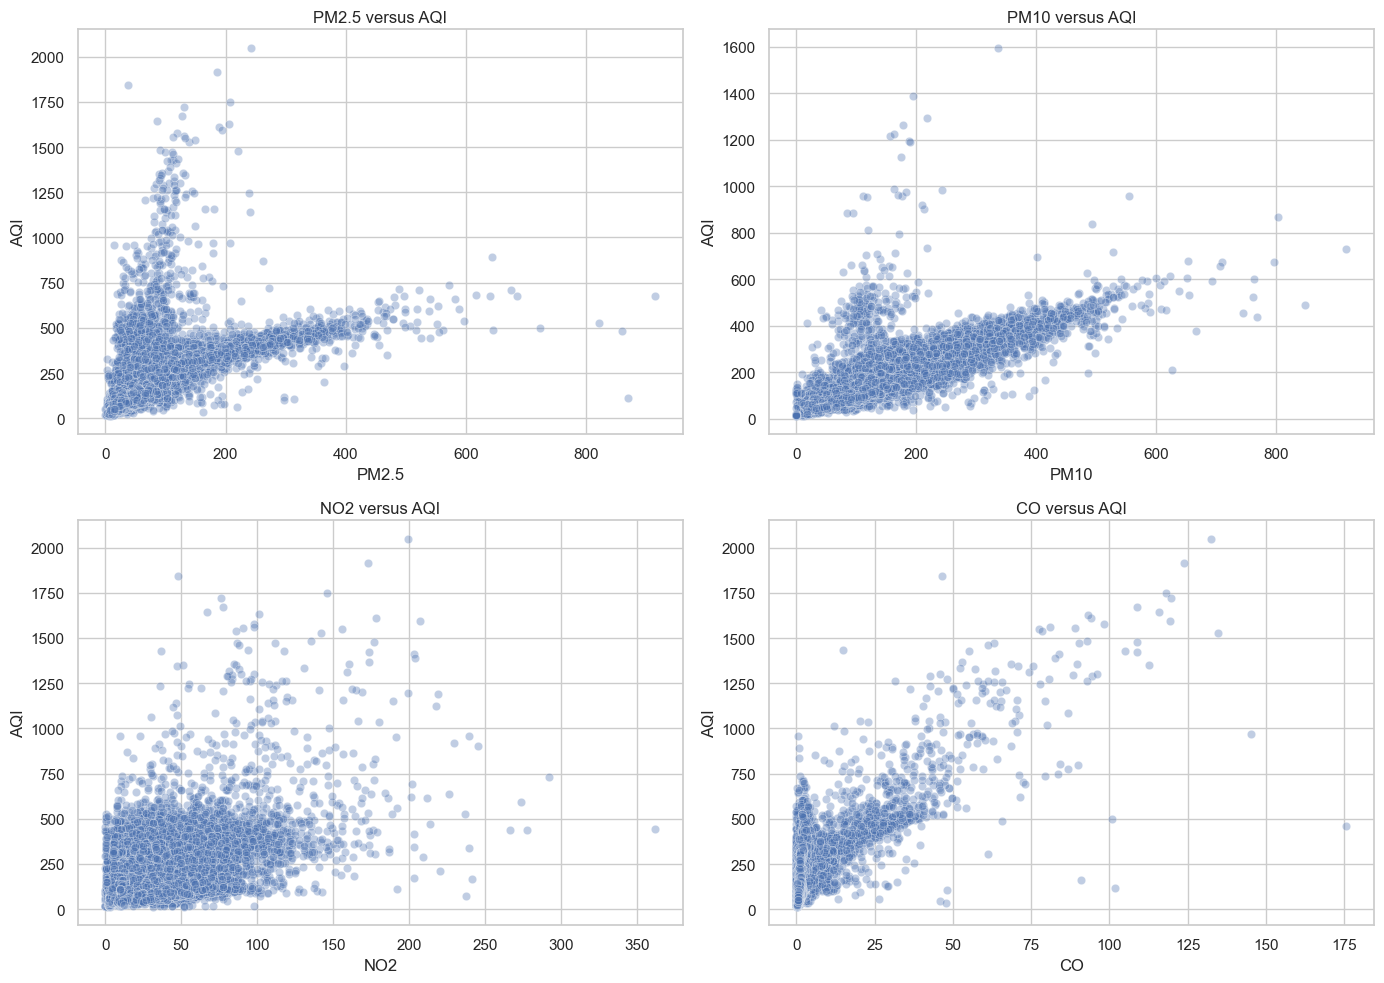

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, pollutant in zip(axes.ravel(), ["PM2.5", "PM10", "NO2", "CO"]):
    sns.scatterplot(data=clean_data, x=pollutant, y="AQI", alpha=0.35, ax=ax)
    ax.set_title(f"{pollutant} versus AQI")
plt.tight_layout()
plt.show()


The scatter plots show positive associations between AQI and several pollutants, especially PM2.5, PM10, and CO. The relationships are not perfectly linear and contain dispersion, which supports the use of non-linear models such as Random Forest. These patterns should be interpreted as associations within the dataset, not as proof of direct causation.


,Year,Mean_AQI
0,2015,212.463054
1,2016,197.150019
2,2017,181.472789
3,2018,182.684312
4,2019,156.518173
5,2020,113.520697


,Month,Month_Name,Mean_AQI
0,1,January,231.674918
1,2,February,202.905197
2,3,March,164.735281
3,4,April,143.355120
4,5,May,135.489579
5,6,June,120.198379
6,7,July,111.854575
7,8,August,113.613176
8,9,September,115.191804
9,10,October,188.613552


,Season,Mean_AQI
3,Winter,220.610764
2,Summer,147.670392
0,Monsoon,115.555426
1,Post-Monsoon,215.473464


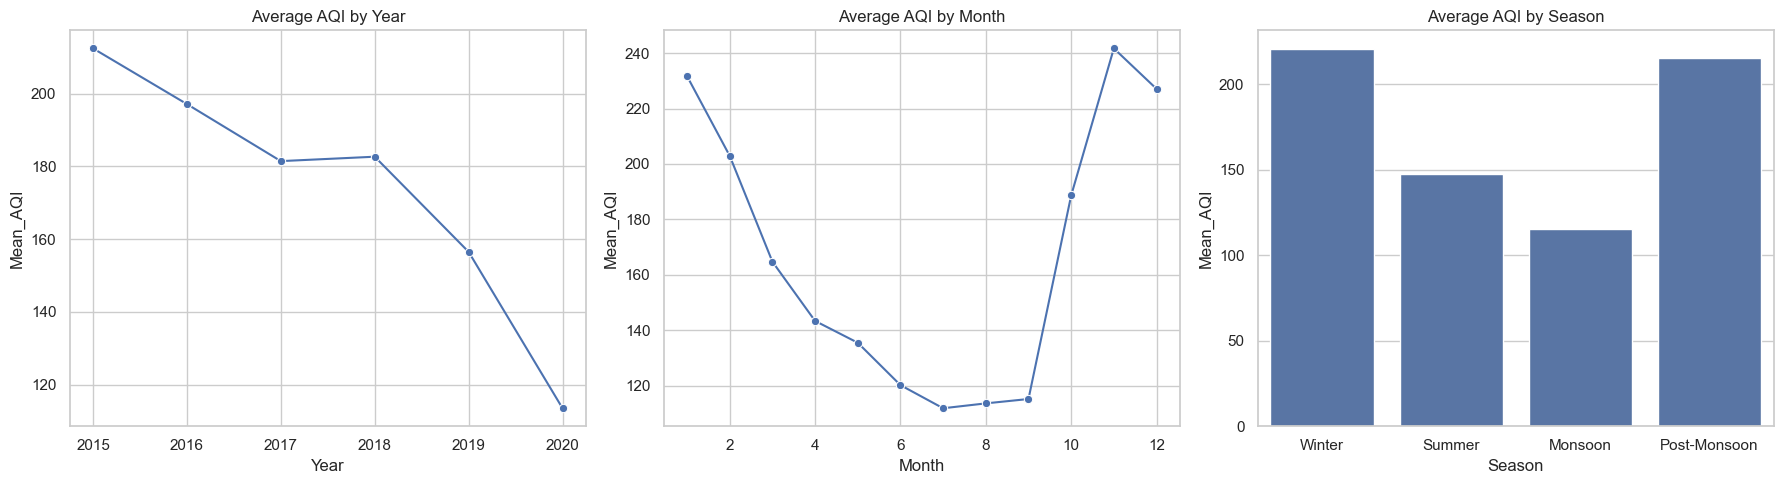

In [13]:
display(yearly_aqi_summary(clean_data))
display(monthly_aqi_summary(clean_data))
display(seasonal_aqi_summary(clean_data))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(data=yearly_aqi_summary(clean_data), x="Year", y="Mean_AQI", marker="o", ax=axes[0])
axes[0].set_title("Average AQI by Year")
sns.lineplot(data=monthly_aqi_summary(clean_data), x="Month", y="Mean_AQI", marker="o", ax=axes[1])
axes[1].set_title("Average AQI by Month")
sns.barplot(data=seasonal_aqi_summary(clean_data), x="Season", y="Mean_AQI", ax=axes[2])
axes[2].set_title("Average AQI by Season")
plt.tight_layout()
plt.show()


The temporal analysis indicates that November has the highest average AQI by month, and winter has the highest average AQI by season. This suggests a seasonal pollution pattern in the dataset. However, the annual trend should be interpreted cautiously because the set of cities contributing to each year changes over time.


## Multivariate Analysis


,Variable,Correlation_with_AQI,Absolute_Correlation
1,PM10,0.803313,0.803313
6,CO,0.683346,0.683346
0,PM2.5,0.659181,0.659181
3,NO2,0.537071,0.537071
7,SO2,0.490586,0.490586
4,NOx,0.486450,0.486450
2,NO,0.452191,0.452191
10,Toluene,0.279992,0.279992
5,NH3,0.252019,0.252019
8,O3,0.198991,0.198991


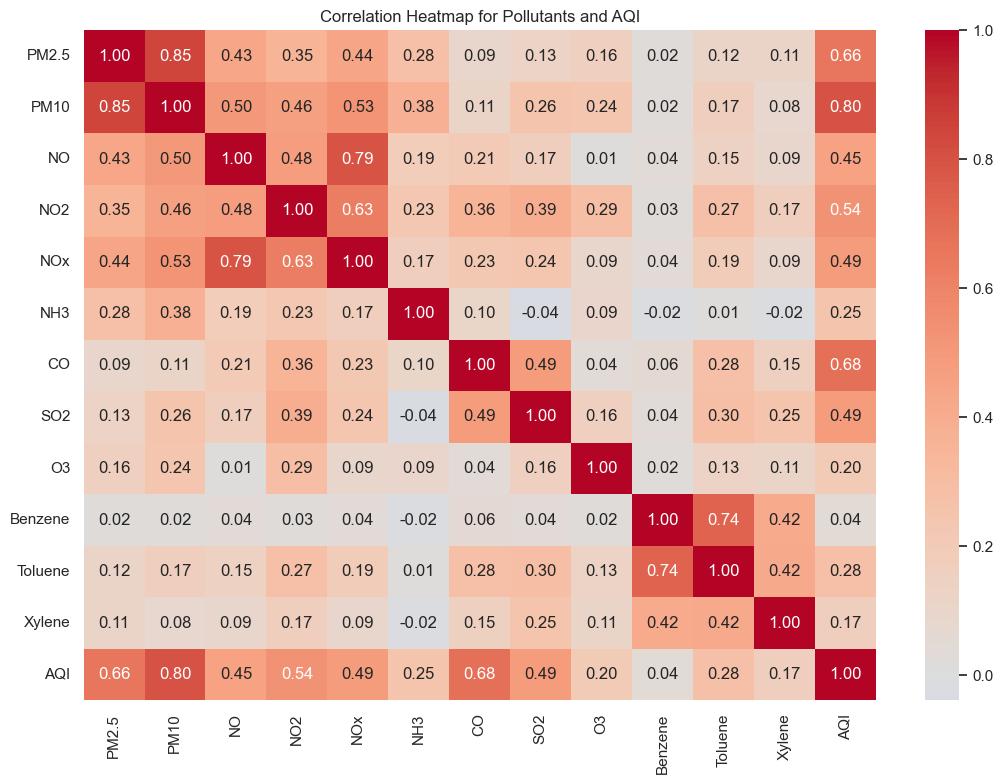

In [14]:
corr = pollutant_correlations(clean_data)
ranked_corr = ranked_aqi_correlations(clean_data)
display(ranked_corr)

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap for Pollutants and AQI")
plt.tight_layout()
plt.show()


The ranked correlations show that PM10, CO, PM2.5, NO2, and SO2 have the strongest positive correlations with AQI in this dataset. This supports their relevance for AQI prediction. Correlation does not establish causation, and the results may also be influenced by measurement availability, city composition, and the way AQI is calculated.


## Unequal City Coverage Check


Comparable-coverage cities: ['Ahmedabad', 'Bengaluru', 'Chennai', 'Delhi', 'Hyderabad', 'Lucknow', 'Patna']
Rows in comparable subset: 13909


,Year,Mean_AQI
0,2015,212.463054
1,2016,201.093592
2,2017,185.019861
3,2018,231.598661
4,2019,206.654574
5,2020,139.620094


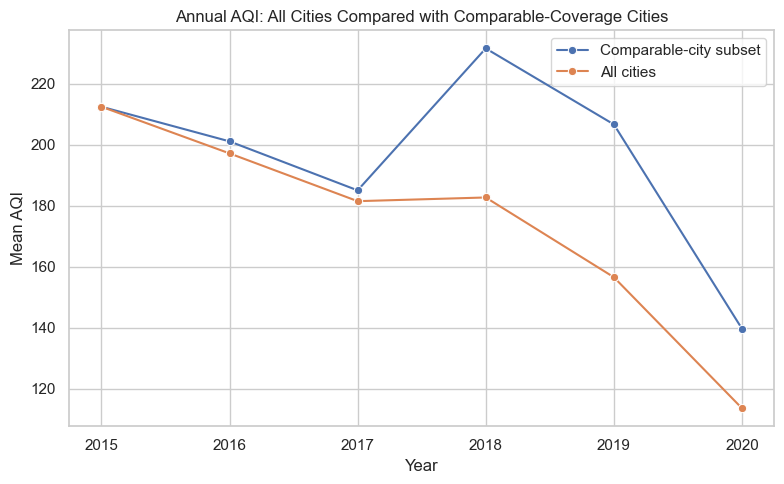

In [15]:
comparable = comparable_city_subset(clean_data)
print("Comparable-coverage cities:", sorted(comparable["City"].unique()))
print("Rows in comparable subset:", len(comparable))
display(yearly_aqi_summary(comparable))

plt.figure(figsize=(8, 5))
sns.lineplot(data=yearly_aqi_summary(comparable), x="Year", y="Mean_AQI", marker="o", label="Comparable-city subset")
sns.lineplot(data=yearly_aqi_summary(clean_data), x="Year", y="Mean_AQI", marker="o", label="All cities")
plt.title("Annual AQI: All Cities Compared with Comparable-Coverage Cities")
plt.ylabel("Mean AQI")
plt.tight_layout()
plt.show()


This comparison reduces the risk of over-interpreting annual averages by focusing on cities with AQI observations spanning the wider study period. Differences between the all-city trend and the comparable-city trend demonstrate why changing city coverage matters. The dataset can support temporal exploration, but it should not be used to claim a national improvement or decline without accounting for city entry dates and missingness.


## Key EDA Findings and Limitations

The EDA indicates that AQI and pollutant values are skewed, missingness is substantial for several variables, Ahmedabad records the highest mean AQI in the available data, November and winter have the highest average AQI, and PM10, CO, and PM2.5 show the strongest correlations with AQI. The main limitation is unequal city coverage, meaning city and annual comparisons must be interpreted as patterns in the supplied dataset rather than definitive national conclusions.


# Task 3: Model Building

## Prediction Objective and Leakage Prevention

The modelling objective is to predict numerical AQI using pollutant measurements, city, year, and month. This is a regression problem. `AQI_Bucket` is excluded because it is derived from AQI and would leak information about the target into the predictors.


In [16]:
model_data = prepare_model_data(clean_data)
print("Rows with available AQI target:", len(model_data))
print("Feature columns:", get_feature_columns())
print("Target column: AQI")


Rows with available AQI target: 24850
Feature columns: ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene', 'City', 'Year', 'Month']
Target column: AQI


## Model Comparison and Optimisation


In [17]:
model_results = pd.read_csv(RESULTS_PATH)
display(model_results)
with open(PROJECT_ROOT / "models" / "model_optimisation.json", "r", encoding="utf-8") as file:
    optimisation = json.load(file)
print("Random Forest parameter grid tested in the pipeline:")
print("n_estimators: [100, 150]; max_depth: [12, 16, None]; min_samples_leaf: [1, 2]; cv=3")
print("Best parameters:", optimisation["best_params"])
print("Cross-validation RMSE:", optimisation["cv_rmse"])


,Model,R2,MAE,MSE,RMSE
0,Random Forest,0.911537,20.511889,1619.845776,40.247308
1,Tuned Random Forest,0.909918,20.370320,1649.494410,40.613968
2,Gradient Boosting,0.899069,23.122529,1848.146516,42.990075
3,Decision Tree,0.863667,24.535697,2496.392230,49.963909
4,Linear Regression,0.824420,29.977477,3215.053811,56.701445


Random Forest parameter grid tested in the pipeline:
n_estimators: [100, 150]; max_depth: [12, 16, None]; min_samples_leaf: [1, 2]; cv=3
Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 150}
Cross-validation RMSE: 43.9558


The untuned Random Forest has the lowest test RMSE in the final comparison table. GridSearchCV identified a tuned Random Forest configuration, but the tuned model produced a slightly worse RMSE than the untuned Random Forest, although its MAE was marginally lower. The final saved model therefore remains the untuned Random Forest because model selection is based on overall test evidence rather than the assumption that tuning must improve performance.


## Final Model Evaluation and Interpretation


,Split,R2,MAE,MSE,RMSE
0,Train,0.977215,12.787409,459.454835,21.434898
1,Test,0.911537,20.511889,1619.845776,40.247308


,Feature,Importance
0,PM2.5,0.494550
6,CO,0.369445
2,NO,0.035670
1,PM10,0.035233
8,O3,0.012252
4,NOx,0.009528
7,SO2,0.007860
3,NO2,0.005767
10,Toluene,0.005728
11,Xylene,0.005266


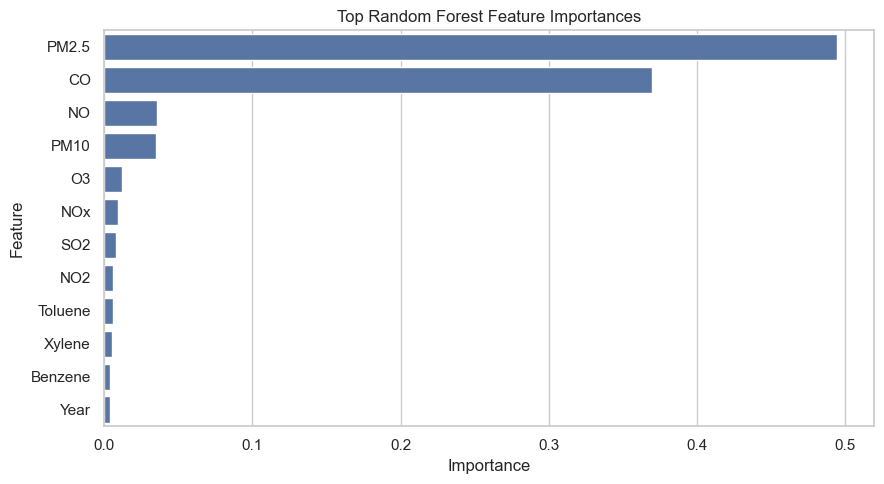

In [18]:
final_model = load_model(MODEL_PATH)
best_model, _, splits = train_and_compare_models(clean_data)
X_train, X_test, y_train, y_test = splits
train_test = training_test_metrics(best_model, X_train, X_test, y_train, y_test)
display(train_test)
importance = feature_importance_table(best_model, top_n=12)
display(importance)

plt.figure(figsize=(9, 5))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Top Random Forest Feature Importances")
plt.tight_layout()
plt.show()


The training RMSE is lower than the testing RMSE, which is expected for a flexible ensemble model. The gap suggests some overfitting risk, but the test R squared remains strong. Feature importance indicates that PM2.5 and CO are the most influential predictors in the fitted Random Forest, followed by other pollutants. Feature importance describes how the model uses variables for prediction; it does not prove that those variables cause AQI changes.


## Model Limitations

The model predicts AQI from pollutant measurements and simple temporal/city features. It is an AQI prediction model, not a future forecasting system, because it does not forecast future pollutant values. Its performance depends on the quality and completeness of the supplied dataset, and predictions should be treated as academic outputs rather than official environmental or health advice.


# Task 4: Application Development

## Application Architecture

The Streamlit application is implemented in `app/app.py` with page modules in `app/pages/`. It uses reusable project modules from `src/` and loads the saved model from `models/trained_model.pkl`. The user-facing sections are Data Overview, Exploratory Data Analysis, and Modelling and Prediction.


In [19]:
print("Application entry point: app/app.py")
print("Data Overview page: app/pages/data_overview.py")
print("EDA page: app/pages/eda.py")
print("Prediction page: app/pages/prediction.py")
print("Navigation configuration: .streamlit/config.toml")


Application entry point: app/app.py
Data Overview page: app/pages/data_overview.py
EDA page: app/pages/eda.py
Prediction page: app/pages/prediction.py
Navigation configuration: .streamlit/config.toml


The Data Overview page displays record counts, city counts, formatted date coverage, pollutant variables, preview rows, missing values, AQI statistics, and AQI category distribution. The EDA page provides interactive filters and charts. The Prediction page allows the user to enter pollutant values and returns a predicted AQI and estimated AQI category.


## Application Screenshots


assets/screenshots/streamlit_data_overview.png exists: True


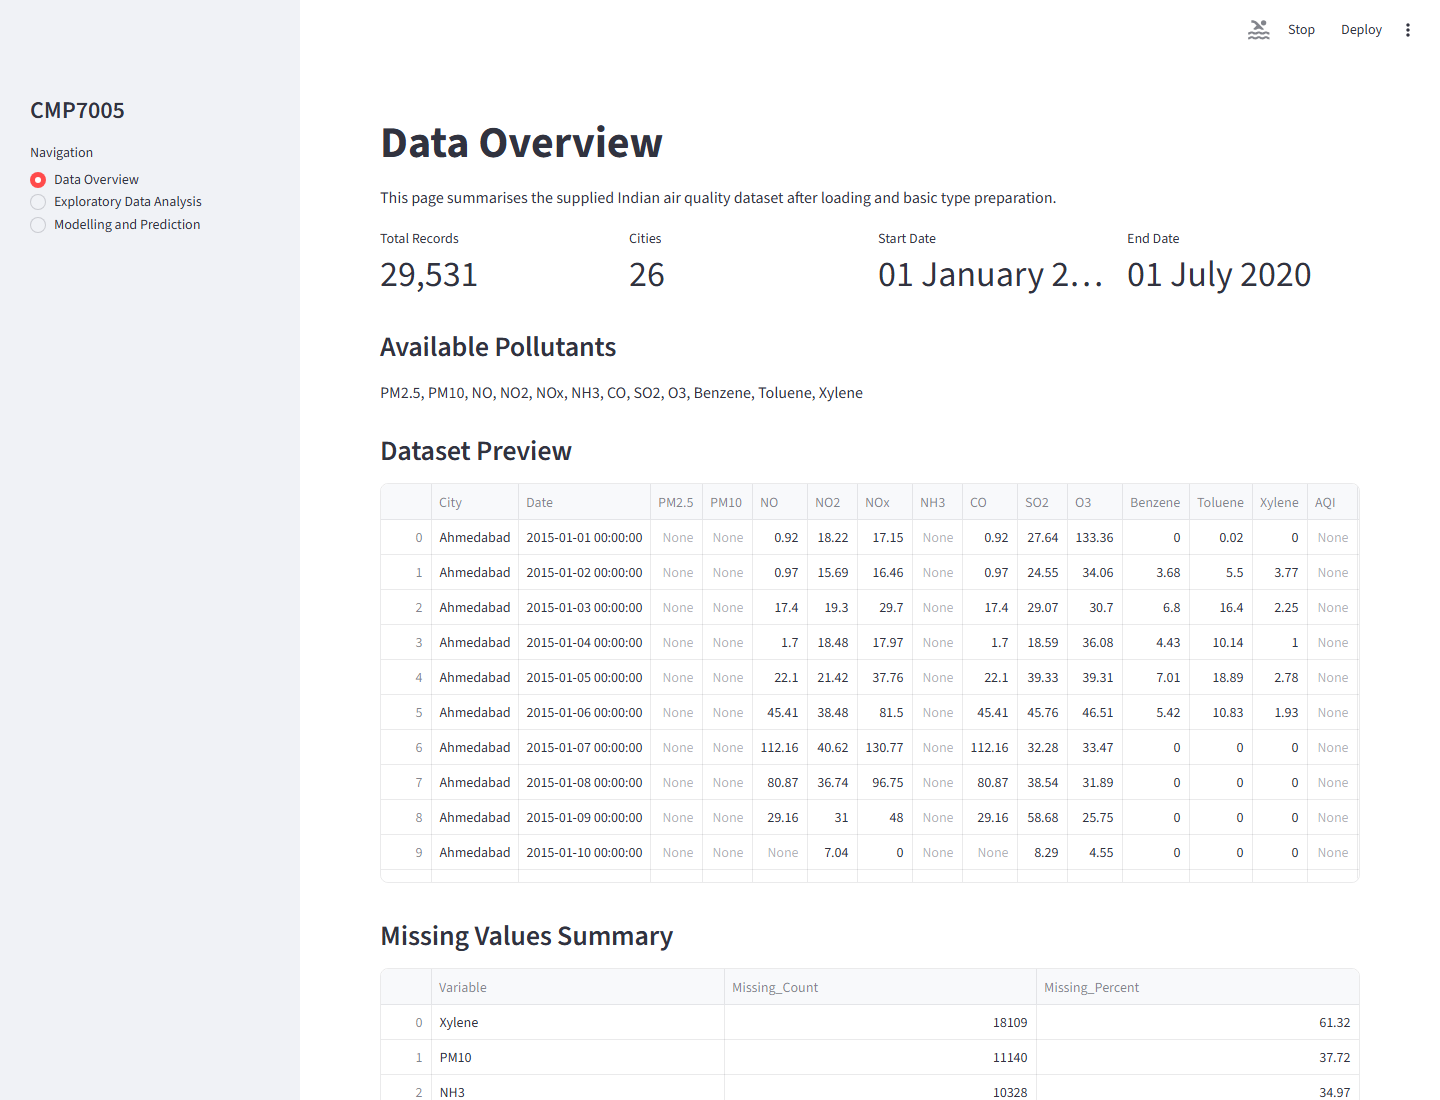

assets/screenshots/streamlit_eda.png exists: True


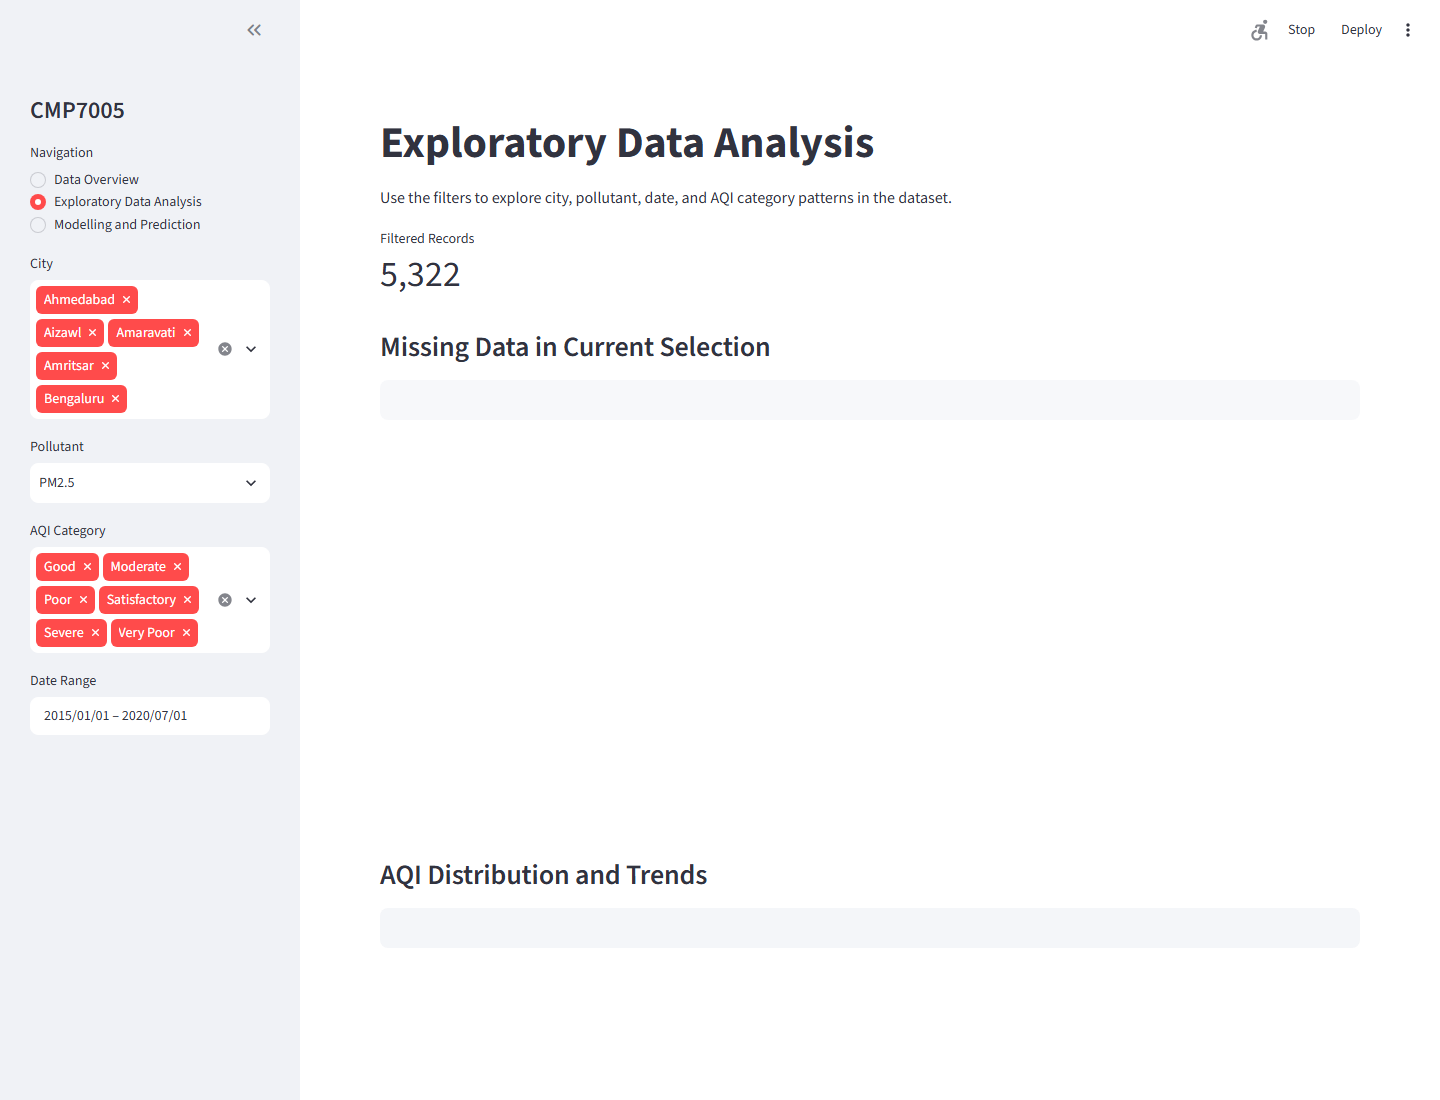

assets/screenshots/streamlit_prediction.png exists: True


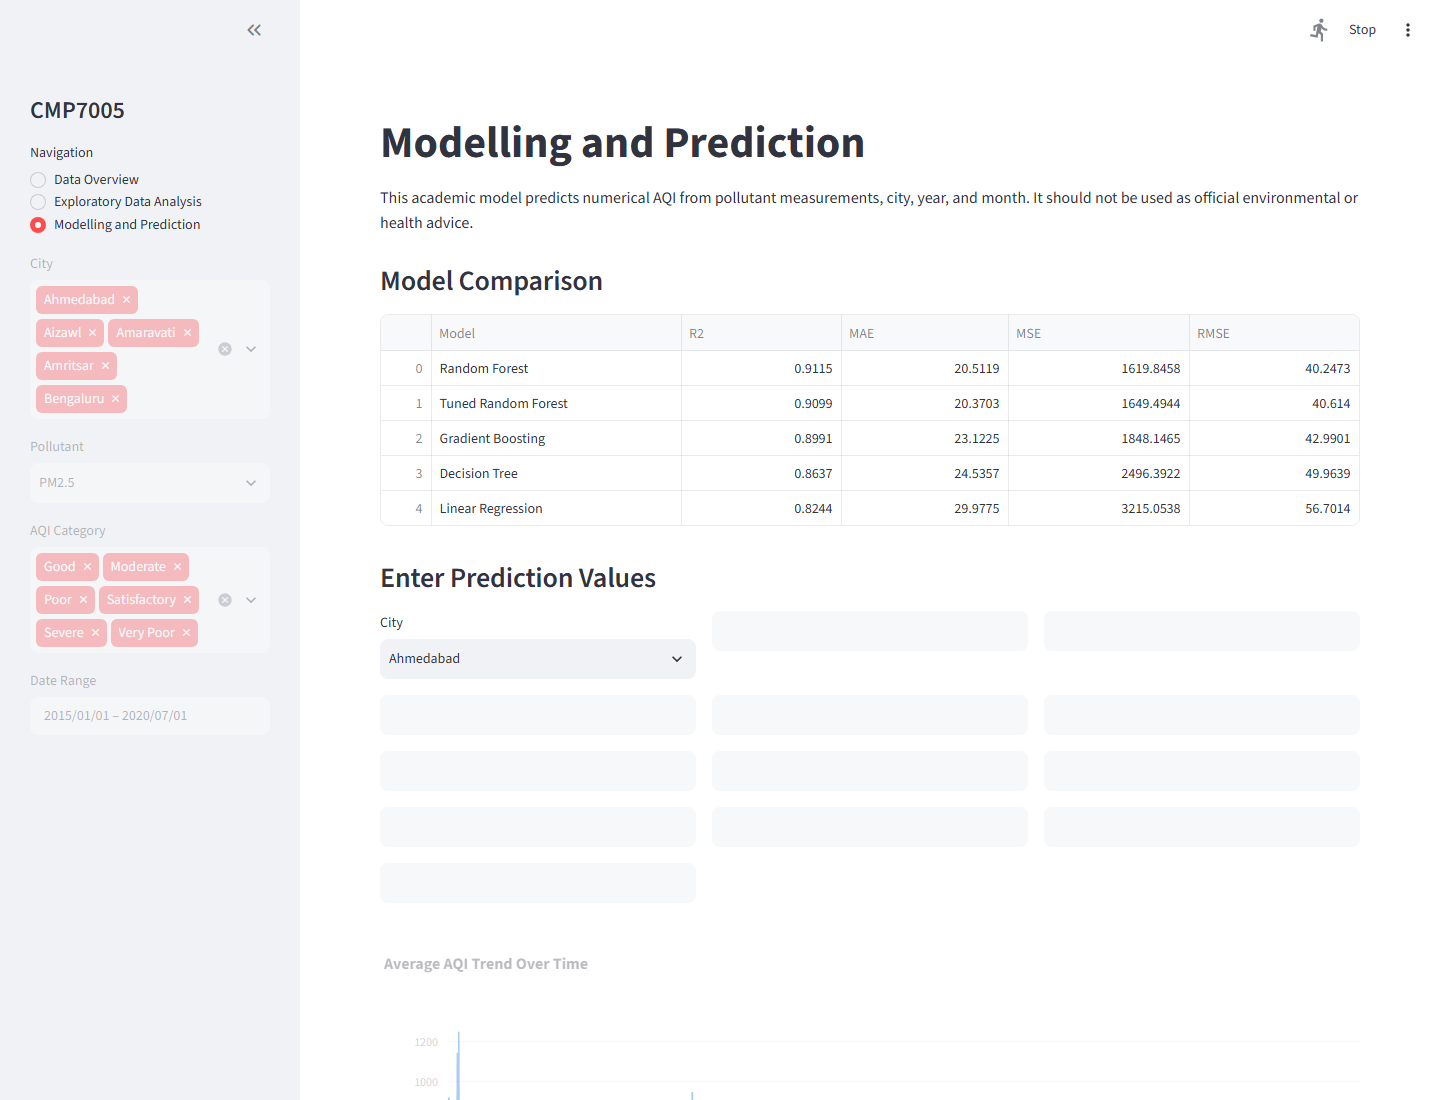

In [20]:
screenshot_paths = [
    "assets/screenshots/streamlit_data_overview.png",
    "assets/screenshots/streamlit_eda.png",
    "assets/screenshots/streamlit_prediction.png",
]
for path in screenshot_paths:
    full_path = PROJECT_ROOT / path
    print(path, "exists:", full_path.exists())
    if full_path.exists():
        display(Image(filename=str(full_path), width=900))


The screenshots demonstrate that the application pages render from the actual project rather than from mocked outputs. They also provide visual evidence for the GUI development requirement.


# Task 5: Version Control

The final repository is hosted at `https://github.com/GursevakSingh-ui/CMP7005_PRAC1_Final`. The commit history documents development stages including project setup, data loading, reusable modules, modelling, Streamlit pages, notebook outputs, screenshots, author correction, and final repair work.


assets/screenshots/github_repository_structure.png exists: True


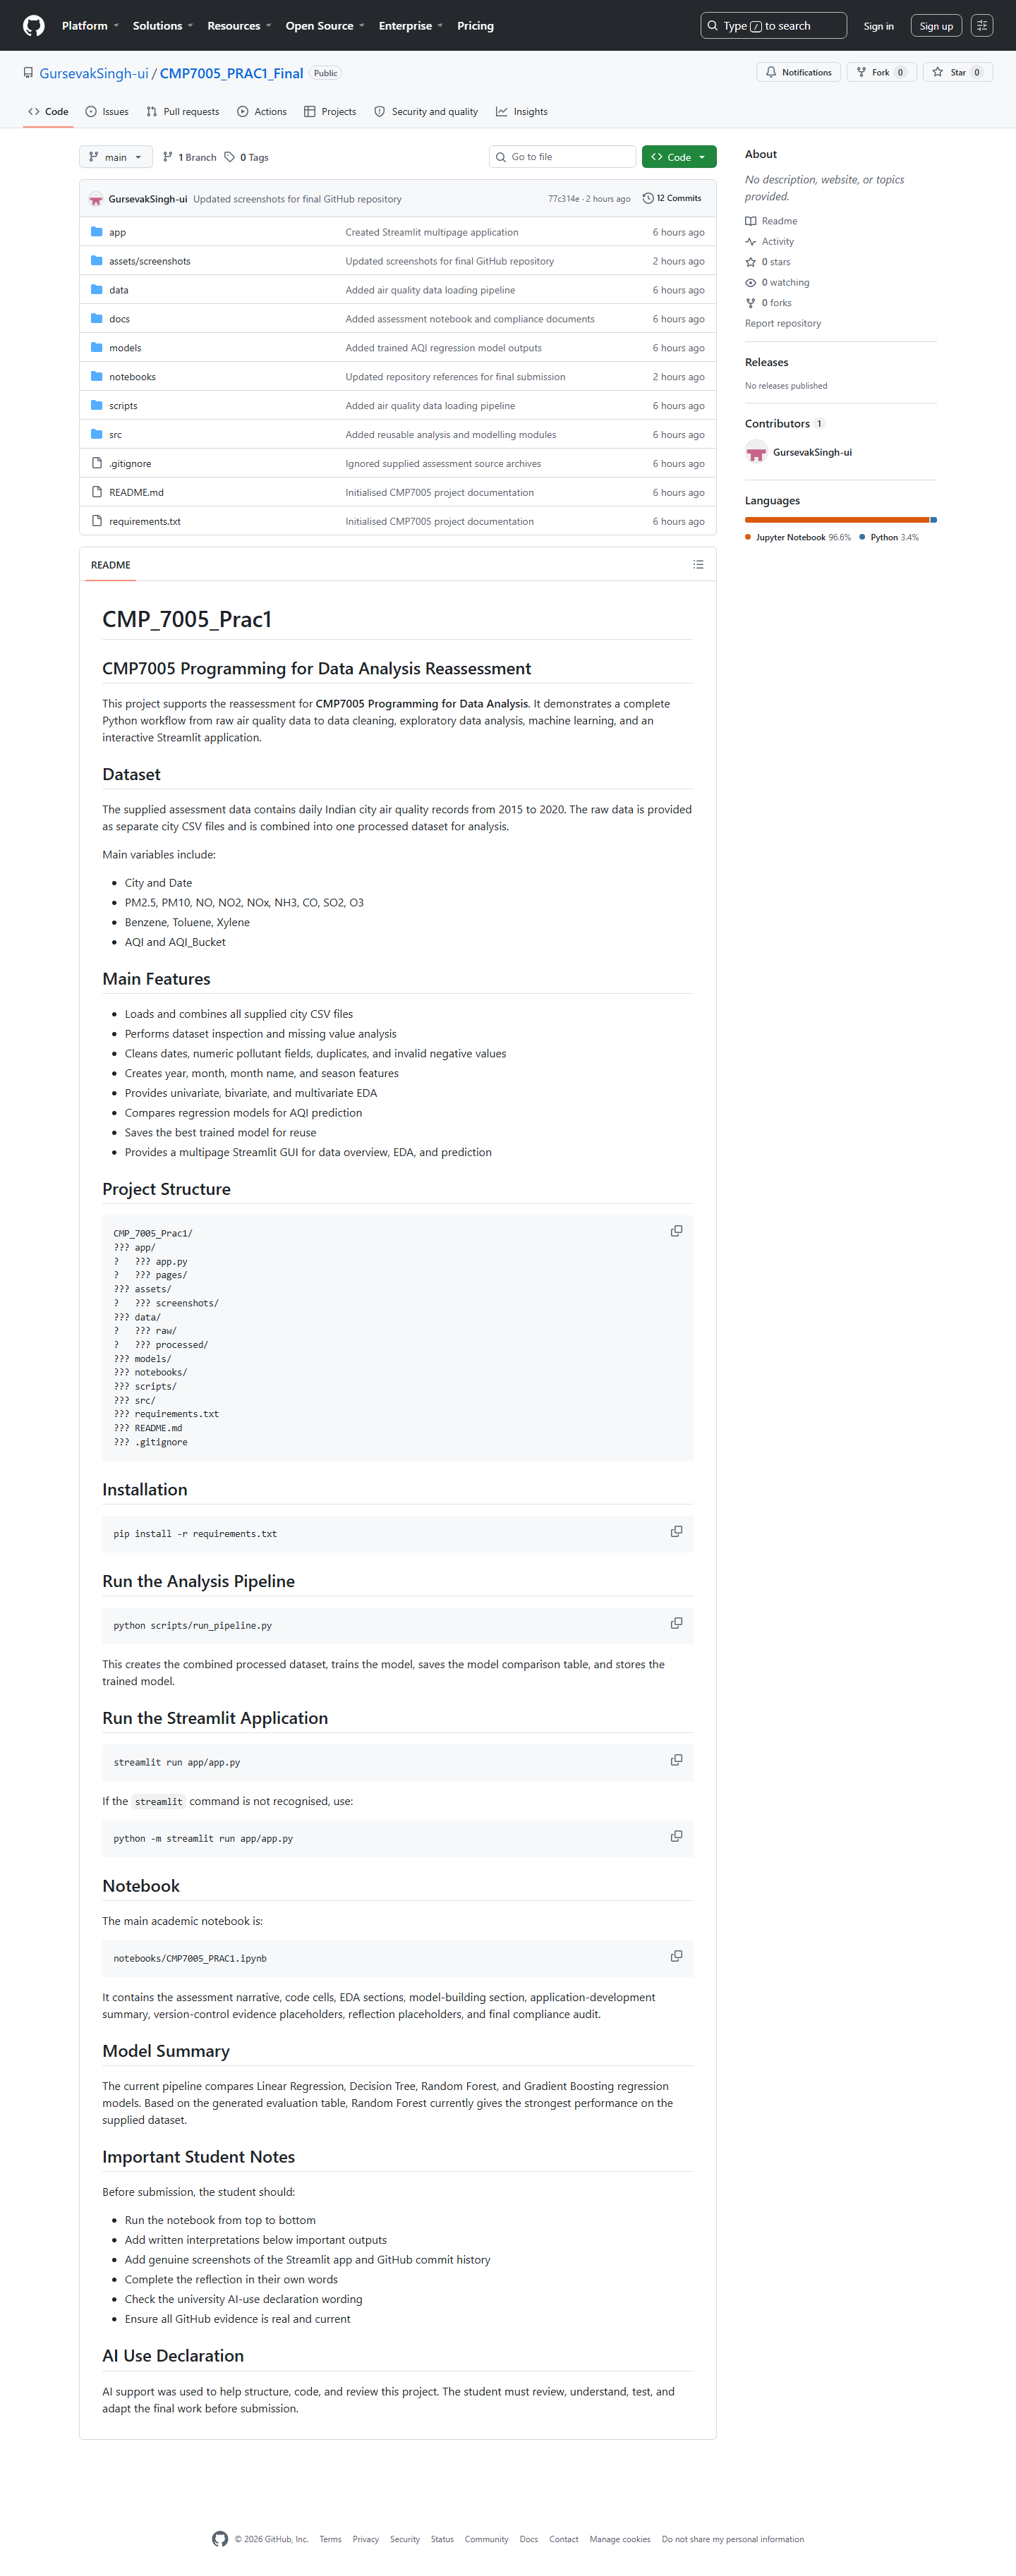

assets/screenshots/github_commit_history.png exists: True


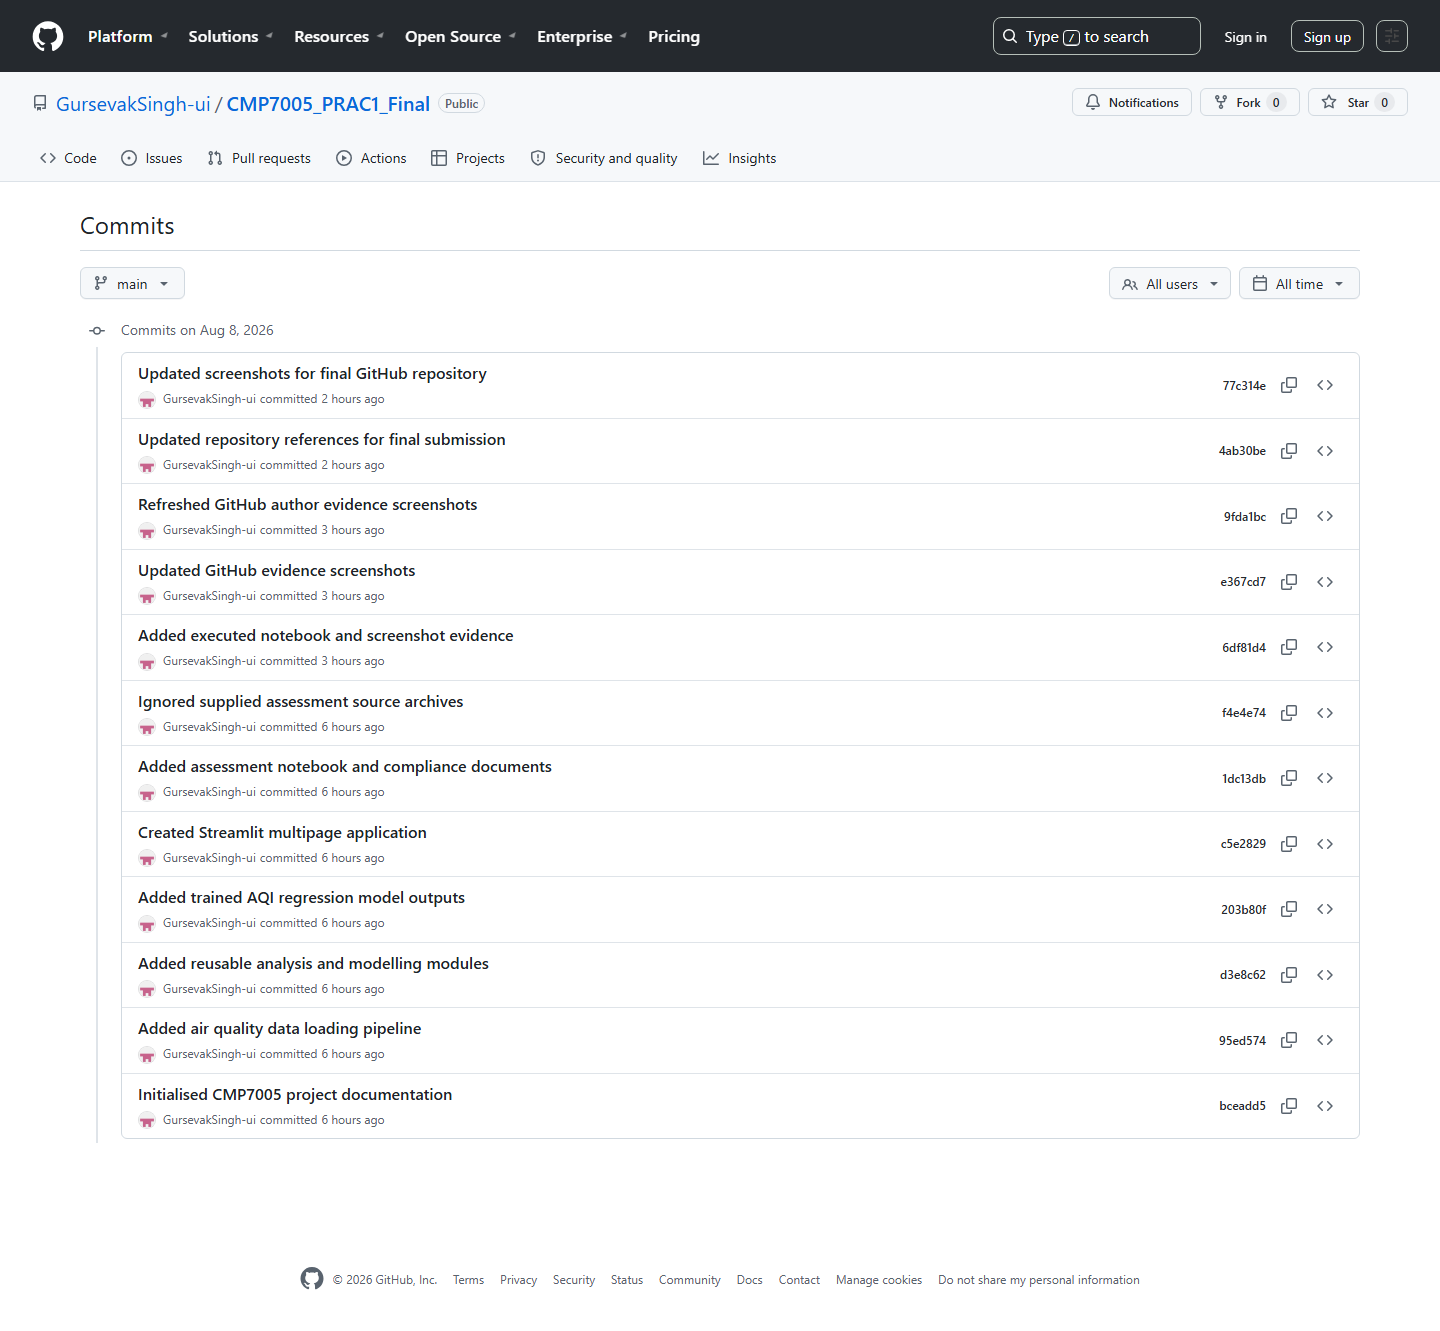

In [21]:
github_screenshots = [
    "assets/screenshots/github_repository_structure.png",
    "assets/screenshots/github_commit_history.png",
]
for path in github_screenshots:
    full_path = PROJECT_ROOT / path
    print(path, "exists:", full_path.exists())
    if full_path.exists():
        display(Image(filename=str(full_path), width=900))


The repository structure screenshot demonstrates that the project is organised into code, data, notebook, model, documentation, and screenshots. The commit-history screenshot demonstrates the use of GitHub for version-control evidence.


# CMP7005 Self Reflection

## Project Development Experience

This project developed from a set of separate city-level CSV files into a structured Python data analysis and application project. The work required data loading, inspection, preprocessing, exploratory data analysis, model building, Streamlit interface development, and GitHub version control. A key learning point was that the assessment was not only about air pollution, but about demonstrating a complete and reproducible programming workflow.

## Data Handling Challenges

One of the first challenges was combining 26 separate city datasets while keeping the original files unchanged. The files shared the same column structure, which made concatenation appropriate, but the combined dataset still needed validation. The project therefore checks expected columns, parses the Date column, confirms dimensions, and preserves both raw and processed data. This made the workflow easier to explain and reproduce.

## Data Quality Challenges

The dataset contains substantial missing data, especially for variables such as Xylene, PM10, NH3, Toluene, and AQI. This made it unsuitable to apply one simple missing-value treatment to every column. Missing target AQI values cannot be artificially filled for supervised learning because that would create unreliable labels. In contrast, missing predictor values can be handled inside the machine-learning pipeline using median imputation. This distinction improved my understanding of how data cleaning decisions depend on the purpose of the analysis.

## EDA Challenges

A major improvement in the project was moving from producing charts to interpreting what those charts show. The EDA had to consider pollutant distributions, AQI category counts, city-level differences, seasonal patterns, and pollutant relationships. A further challenge was unequal temporal coverage: some cities have data from 2015, while others enter much later. This means that overall annual AQI trends must be interpreted cautiously because changes may reflect changing city composition as well as pollution changes.

## Model Development Challenges

The modelling task required careful feature preparation. AQI_Bucket was excluded because it is derived from AQI and would create target leakage. The project compares Linear Regression, Decision Tree, Random Forest, and Gradient Boosting models using MAE, MSE, RMSE, and R squared. Random Forest performed best on the test set. Hyperparameter tuning was also tested using GridSearchCV, but the tuned model did not improve RMSE enough to replace the original Random Forest. This showed that optimisation should be judged by evidence rather than assumed to improve results.

## Application Development Challenges

The Streamlit application required the analysis to be presented in a usable graphical interface. The app includes Data Overview, EDA, and Prediction sections. During testing, the Data Overview page needed a repair because Streamlit metric components require display-friendly values, so dates were converted into formatted strings. The EDA page was also strengthened to handle empty filtered results and to show clearer evidence of missing data, temporal analysis, city comparison, pollutant relationships, and correlations.

## Version Control

GitHub was used to document the development stages. Commits were organised around project setup, data loading, reusable modules, modelling outputs, Streamlit application development, notebook completion, screenshot evidence, and final repairs. This helped create a clearer development history and supported the version-control learning outcome.

## Skills Developed

The project developed practical skills in pandas data handling, reusable Python modules, exploratory visualisation, missing-data reasoning, scikit-learn pipelines, model evaluation, hyperparameter tuning, feature importance interpretation, Streamlit application development, and GitHub version control. It also improved my ability to write cautious academic interpretations based on actual program outputs.

## Areas for Further Improvement

If the project were extended, I would carry out deeper sensitivity analysis around highly incomplete pollutants, add more formal statistical tests for selected comparisons, and perform broader model validation. I would also improve the application with more guided chart explanations and more systematic user testing. If specific previous assessment feedback is available, it should be added here by the student in their own words; no specific previous-feedback document was available in the repository during this repair work.


# Overall Conclusion

This project demonstrates the full workflow required by the CMP7005 reassessment. The raw city CSV files were combined into a validated dataset, cleaned through reproducible preprocessing functions, and analysed through descriptive, temporal, city-level, and multivariate EDA. The analysis found substantial missingness in several variables, strong AQI associations with PM10, CO, and PM2.5, higher average AQI in November and winter, and important limitations caused by unequal city coverage. The modelling section compared several regression approaches and selected Random Forest as the final model because it produced the strongest RMSE on the test set. The Streamlit application provides a functional interface for dataset overview, interactive EDA, and AQI prediction. Overall, the project meets the assessment aim of moving from raw data to a working analytical application while maintaining reproducibility, modular code, and cautious interpretation.


# References

Central Pollution Control Board (2014) *National Air Quality Index*. New Delhi: Central Pollution Control Board, Ministry of Environment, Forests and Climate Change, Government of India. Available at: https://cpcb.nic.in/.

McKinney, W. (2010) 'Data structures for statistical computing in Python', *Proceedings of the 9th Python in Science Conference*, pp. 56-61.

Pedregosa, F. et al. (2011) 'Scikit-learn: Machine learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825-2830.

Tukey, J.W. (1977) *Exploratory Data Analysis*. Reading, MA: Addison-Wesley.

World Health Organization (2021) *WHO global air quality guidelines: particulate matter (PM2.5 and PM10), ozone, nitrogen dioxide, sulfur dioxide and carbon monoxide*. Geneva: World Health Organization. Available at: https://www.who.int/publications/i/item/9789240034228.

Streamlit (2026) *Streamlit documentation*. Available at: https://docs.streamlit.io/.


# AI Use Declaration

AI support was used to assist with project structuring, code repair, documentation, and assessment review. The final work remains based on the supplied dataset and executed project outputs. No analytical results, screenshots, model scores, or previous feedback have been fabricated.
